# Etapa 1: EDA + ML Canvas + Baselines
## Projeto: Previsão de Churn em Telecomunicações

**Objetivo**: Exploração completa do dataset, definição de métricas de negócio e técnicas, e treinamento de baselines.

**Dataset**: Telco Customer Churn
- 7,043 clientes | 19 features (pos leakage fix: 11 colunas removidas) | 26.5% churn rate
- Target: `Churn Value` (1 = churn, 0 = no churn)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import logging
import warnings

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Set seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✓ Environment configured with seed =', RANDOM_SEED)

✓ Environment configured with seed = 42


## 1. Loading and Initial Data Treatment

In [2]:
# Load dataset
data_path = Path.cwd().parent / 'data' / 'raw' / 'Telco_customer_churn.xlsx'
print(f'✓ Loading data from: {data_path}')

df = pd.read_excel(data_path)
logger.info(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')

print('\n=== DATASET INFO ===')
print(f'Shape: {df.shape}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print(f'\nFirst 5 rows:')
print(df.head())

✓ Loading data from: c:\Users\leand\Documents\git\Telecommunications_Industry\data\raw\Telco_customer_churn.xlsx


2026-05-05 21:05:09,730 - INFO - Dataset loaded: 7043 rows, 33 columns



=== DATASET INFO ===
Shape: (7043, 33)
Memory: 10.50 MB

First 5 rows:
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month 

## 2. Data Cleaning and Treatment

In [3]:
# Copy to avoid modifying original
df = df.copy()

print('=== DATA CLEANING ===')

# 1. Fix Total Charges (convert from object to numeric)
print('\n1. Fixing Total Charges:')
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
missing_total = df['Total Charges'].isna().sum()
print(f'   - Converted to numeric')
print(f'   - Missing values (non-numeric): {missing_total}')

if missing_total > 0:
    df.loc[df['Total Charges'].isna(), 'Total Charges'] = 0
    print(f'   - Filled with 0 (new customers with Tenure=0)')

# 2. Remove unnecessary columns
print('\n2. Removing redundant columns:')
cols_remove = ['CustomerID', 'Count', 'Lat Long', 'Churn Label']
for col in cols_remove:
    if col in df.columns:
        df = df.drop(columns=[col])
        print(f'   - {col}')

# 3. Check Country and State (unique values)
print(f'\n3. Checking location features:')
print(f'   - Country unique: {df["Country"].nunique()} ({df["Country"].unique()})')
print(f'   - State unique: {df["State"].nunique()} ({df["State"].unique()})')
print(f'   - City unique: {df["City"].nunique()}')

# Remove Country and State if only 1 unique value
cols_remove_unique = [col for col in ['Country', 'State'] if df[col].nunique() == 1]
if cols_remove_unique:
    df = df.drop(columns=cols_remove_unique)
    print(f'   - Removed: {cols_remove_unique}')

# 4. Check missing values
print('\n4. Missing values:')
missing = df.isnull().sum()
missing_with_values = missing[missing > 0]
if missing_with_values.empty:
    print('   ✓ No missing values')
else:
    print(missing_with_values)

# 5. Check duplicates
print(f'\n5. Duplicates: {df.duplicated().sum()}')

print(f'\n✓ Final dataset: {df.shape[0]} rows × {df.shape[1]} columns')

=== DATA CLEANING ===

1. Fixing Total Charges:
   - Converted to numeric
   - Missing values (non-numeric): 11
   - Filled with 0 (new customers with Tenure=0)

2. Removing redundant columns:
   - CustomerID
   - Count
   - Lat Long
   - Churn Label

3. Checking location features:
   - Country unique: 1 (['United States'])
   - State unique: 1 (['California'])
   - City unique: 1129
   - Removed: ['Country', 'State']

4. Missing values:
Churn Reason    5174
dtype: int64

5. Duplicates: 0

✓ Final dataset: 7043 rows × 27 columns


## 3. Target Variable Analysis


=== TARGET VARIABLE ANALYSIS ===

Distribution of Churn Value:
Churn Value
0    5174
1    1869
Name: count, dtype: int64

Proportion:
Churn Value
0    0.7346
1    0.2654
Name: proportion, dtype: float64

📊 Business Metrics:
   - Total customers: 7,043
   - Customers with churn: 1,869
   - Churn rate: 26.54%


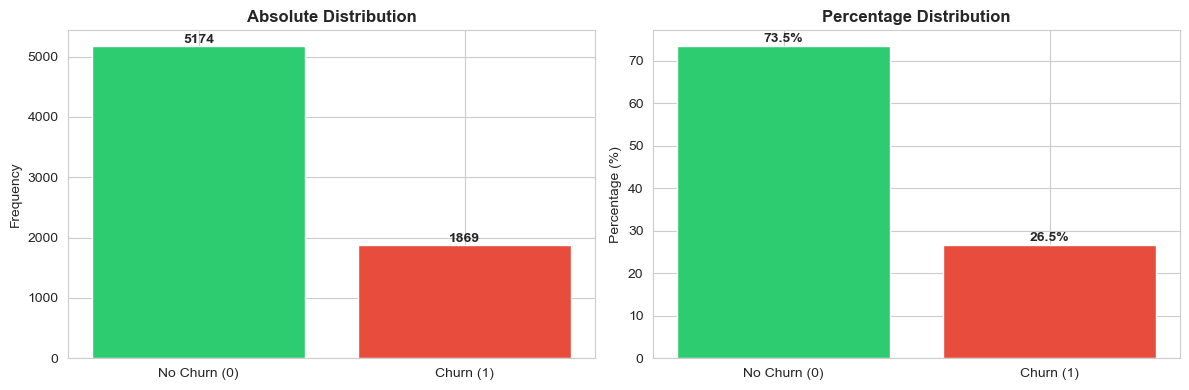


✓ Imbalance: ~26.5% churn (acceptable for classification)


In [4]:
print('\n=== TARGET VARIABLE ANALYSIS ===')

target_col = 'Churn Value'

# Distribution
print(f'\nDistribution of {target_col}:')
print(df[target_col].value_counts())
print(f'\nProportion:')
print(df[target_col].value_counts(normalize=True).round(4))

# Business metrics
n_churn = (df[target_col] == 1).sum()
n_total = len(df)
churn_rate = n_churn / n_total

print(f'\n📊 Business Metrics:')
print(f'   - Total customers: {n_total:,}')
print(f'   - Customers with churn: {n_churn:,}')
print(f'   - Churn rate: {churn_rate:.2%}')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df[target_col].value_counts().sort_index()
axes[0].bar(['No Churn (0)', 'Churn (1)'], counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Absolute Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

props = df[target_col].value_counts(normalize=True).sort_index()
axes[1].bar(['No Churn (0)', 'Churn (1)'], props.values * 100, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Percentage Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
for i, v in enumerate(props.values * 100):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n✓ Imbalance: ~26.5% churn (acceptable for classification)')

## 4. Numeric Features Analysis

In [5]:
# Separate features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != target_col]
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'\n=== NUMERIC FEATURES ({len(numeric_cols)}) ===')
for col in numeric_cols:
    print(f'  - {col}')

print(f'\n=== CATEGORICAL FEATURES ({len(categorical_cols)}) ===')
for col in categorical_cols:
    print(f'  - {col}')

# Descriptive statistics
print(f'\n=== DESCRIPTIVE STATISTICS ===')
print(df[numeric_cols].describe().round(2).T)


=== NUMERIC FEATURES (8) ===
  - Zip Code
  - Latitude
  - Longitude
  - Tenure Months
  - Monthly Charges
  - Total Charges
  - Churn Score
  - CLTV

=== CATEGORICAL FEATURES (18) ===
  - City
  - Gender
  - Senior Citizen
  - Partner
  - Dependents
  - Phone Service
  - Multiple Lines
  - Internet Service
  - Online Security
  - Online Backup
  - Device Protection
  - Tech Support
  - Streaming TV
  - Streaming Movies
  - Contract
  - Paperless Billing
  - Payment Method
  - Churn Reason

=== DESCRIPTIVE STATISTICS ===
                  count      mean      std       min       25%       50%  \
Zip Code         7043.0  93521.96  1865.79  90001.00  92102.00  93552.00   
Latitude         7043.0     36.28     2.46     32.56     34.03     36.39   
Longitude        7043.0   -119.80     2.16   -124.30   -121.82   -119.73   
Tenure Months    7043.0     32.37    24.56      0.00      9.00     29.00   
Monthly Charges  7043.0     64.76    30.09     18.25     35.50     70.35   
Total Charges   

## 5. Correlation with Churn


=== CORRELATION WITH CHURN ===

Top 10 Features by Correlation with Churn:
Churn Score        0.6649
Monthly Charges    0.1934
Longitude          0.0046
Zip Code           0.0033
Latitude          -0.0034
CLTV              -0.1275
Total Charges     -0.1983
Tenure Months     -0.3522
Name: Churn Value, dtype: float64


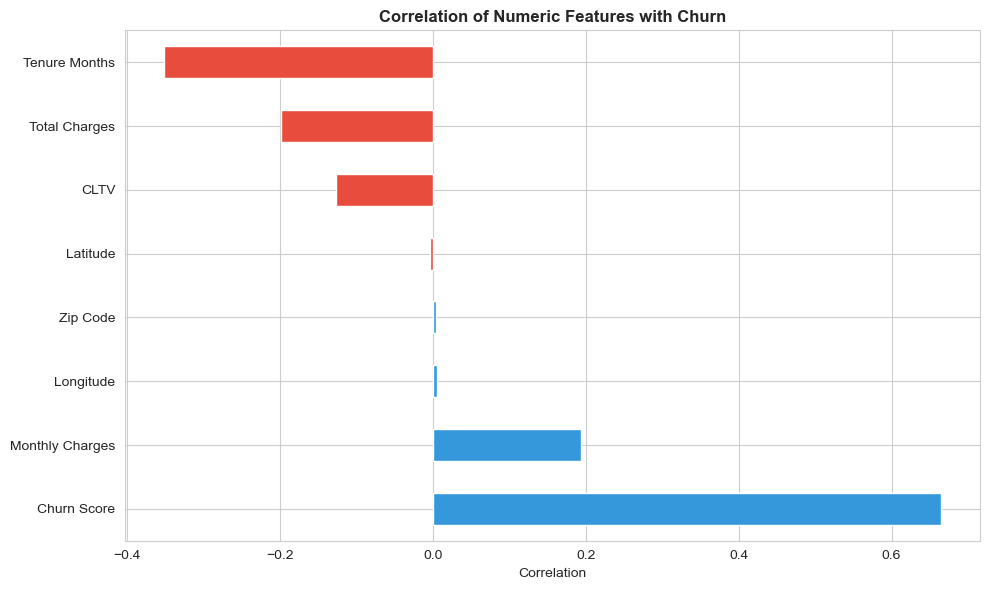


Key Insights:
  1. Churn Score: +0.6649 ↑
  2. Monthly Charges: +0.1934 ↑
  3. Longitude: +0.0046 ↑
  4. Zip Code: +0.0033 ↑
  5. Latitude: -0.0034 ↓


In [6]:
print('\n=== CORRELATION WITH CHURN ===')

# Correlation matrix
df_numeric = df[numeric_cols + [target_col]].copy()
corr_matrix = df_numeric.corr()

# Top features correlated with churn
churn_corr = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)
print('\nTop 10 Features by Correlation with Churn:')
print(churn_corr.head(10).round(4))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#3498db' if x > 0 else '#e74c3c' for x in churn_corr.head(10)]
churn_corr.head(10).plot(kind='barh', ax=ax, color=colors)
ax.set_title('Correlation of Numeric Features with Churn', fontsize=12, fontweight='bold')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.show()

print('\nKey Insights:')
for i, (col, corr_val) in enumerate(churn_corr.head(5).items(), 1):
    direction = '↑' if corr_val > 0 else '↓'
    print(f'  {i}. {col}: {corr_val:+.4f} {direction}')

## 6. Categorical Features Analysis

In [7]:
print('\n=== CATEGORICAL FEATURES ===')

# Cardinality
print('\nCardinality (unique values):')
for col in categorical_cols:
    n_unique = df[col].nunique()
    print(f'  {col:25s}: {n_unique:3d} values')

# Churn rate by important categorical features
print('\n\nChurn Rate by Category (Top 3 features):')

important_cats = ['Internet Service', 'Contract', 'Tech Support']

for col in important_cats:
    if col in df.columns:
        churn_rate_by = df.groupby(col)[target_col].apply(lambda x: (x == 1).sum() / len(x))
        churn_rate_by = churn_rate_by.sort_values(ascending=False)
        
        print(f'\n  {col}:')
        for cat, rate in churn_rate_by.items():
            print(f'    - {cat}: {rate:.2%}')


=== CATEGORICAL FEATURES ===

Cardinality (unique values):
  City                     : 1129 values
  Gender                   :   2 values
  Senior Citizen           :   2 values
  Partner                  :   2 values
  Dependents               :   2 values
  Phone Service            :   2 values
  Multiple Lines           :   3 values
  Internet Service         :   3 values
  Online Security          :   3 values
  Online Backup            :   3 values
  Device Protection        :   3 values
  Tech Support             :   3 values
  Streaming TV             :   3 values
  Streaming Movies         :   3 values
  Contract                 :   3 values
  Paperless Billing        :   2 values
  Payment Method           :   4 values
  Churn Reason             :  20 values


Churn Rate by Category (Top 3 features):

  Internet Service:
    - Fiber optic: 41.89%
    - DSL: 18.96%
    - No: 7.40%

  Contract:
    - Month-to-month: 42.71%
    - One year: 11.27%
    - Two year: 2.83%

  Tech 

## 7. Data Readiness Checklist

In [8]:
print('\n=== DATA READINESS CHECKLIST ===')

readiness_checks = {
    'Missing values handled': df.isnull().sum().sum() == 0,
    'No duplicates': df.duplicated().sum() == 0,
    'Data types correct': len(numeric_cols) > 0 and len(categorical_cols) > 0,
    'Target variable identified': target_col in df.columns,
    'Sufficient features': (len(numeric_cols) + len(categorical_cols)) >= 10,
    'Acceptable imbalance': 0.2 < (n_churn / n_total) < 0.8,
    'Total Charges processed': 'Total Charges' in df.columns and df['Total Charges'].dtype != 'object',
}

print()
for check, status in readiness_checks.items():
    icon = '✓' if status else '✗'
    status_str = 'READY' if status else 'ATTENTION'
    print(f'{icon} {check:40s}: {status_str}')

all_ready = all(readiness_checks.values())
print(f'\n{"✓" if all_ready else "✗"} Overall Status: {"READY FOR MODELING" if all_ready else "REVIEW NEEDED"}')


=== DATA READINESS CHECKLIST ===

✗ Missing values handled                  : ATTENTION
✓ No duplicates                           : READY
✓ Data types correct                      : READY
✓ Target variable identified              : READY
✓ Sufficient features                     : READY
✓ Acceptable imbalance                    : READY
✓ Total Charges processed                 : READY

✗ Overall Status: REVIEW NEEDED


## 8. Feature Preparation for Modeling

In [9]:
print('\n=== FEATURE PREPARATION ===')

# Separate X and y
X = df.drop(columns=[target_col])
y = df[target_col]

print(f'\nX shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nTarget distribution:')
print(y.value_counts())

# Encode categorical features
X_encoded = X.copy()
label_encoders = {}

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

print(f'\nEncoding categorical features ({len(categorical_features)}):') 
for col in categorical_features:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f'  ✓ {col}: {len(le.classes_)} classes')

print(f'\n✓ Features encoded and ready for baseline')


=== FEATURE PREPARATION ===

X shape: (7043, 26)
y shape: (7043,)

Target distribution:
Churn Value
0    5174
1    1869
Name: count, dtype: int64

Encoding categorical features (18):
  ✓ City: 1129 classes
  ✓ Gender: 2 classes
  ✓ Senior Citizen: 2 classes
  ✓ Partner: 2 classes
  ✓ Dependents: 2 classes
  ✓ Phone Service: 2 classes
  ✓ Multiple Lines: 3 classes
  ✓ Internet Service: 3 classes
  ✓ Online Security: 3 classes
  ✓ Online Backup: 3 classes
  ✓ Device Protection: 3 classes
  ✓ Tech Support: 3 classes
  ✓ Streaming TV: 3 classes
  ✓ Streaming Movies: 3 classes
  ✓ Contract: 3 classes
  ✓ Paperless Billing: 2 classes
  ✓ Payment Method: 4 classes
  ✓ Churn Reason: 21 classes

✓ Features encoded and ready for baseline


## 9. Train-Test Split with Stratification

In [10]:
print('\n=== TRAIN-TEST SPLIT ===')

# Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f'\nTrain: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')
print(f'\nTarget distribution (Train): {y_train.value_counts().to_dict()}')
print(f'Churn rate (Train): {(y_train == 1).sum() / len(y_train):.2%}')
print(f'\nTarget distribution (Test): {y_test.value_counts().to_dict()}')
print(f'Churn rate (Test): {(y_test == 1).sum() / len(y_test):.2%}')

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print(f'\n✓ Features scaled with StandardScaler')


=== TRAIN-TEST SPLIT ===

Train: 5634 samples
Test:  1409 samples

Target distribution (Train): {0: 4139, 1: 1495}
Churn rate (Train): 26.54%

Target distribution (Test): {0: 1035, 1: 374}
Churn rate (Test): 26.54%

✓ Features scaled with StandardScaler


## 10. Training Baselines

In [11]:
print('\n=== TRAINING BASELINES ===')

results = {}

# 1. DummyClassifier
print('\n[1] DummyClassifier (always predicts majority class)')
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)

acc_dummy = accuracy_score(y_test, y_pred_dummy)
f1_dummy = f1_score(y_test, y_pred_dummy)
results['DummyClassifier'] = {'accuracy': acc_dummy, 'f1': f1_dummy, 'model': dummy}
print(f'   Accuracy: {acc_dummy:.4f}')
print(f'   F1-Score: {f1_dummy:.4f}')

# 2. Logistic Regression
print('\n[2] Logistic Regression (linear baseline)')
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, n_jobs=-1)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)
results['LogisticRegression'] = {'accuracy': acc_lr, 'f1': f1_lr, 'auc': auc_lr, 'model': lr}
print(f'   Accuracy: {acc_lr:.4f}')
print(f'   F1-Score: {f1_lr:.4f}')
print(f'   AUC-ROC:  {auc_lr:.4f}')

# 3. Random Forest
print('\n[3] Random Forest (ensemble baseline)')
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1, max_depth=15)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)
results['RandomForest'] = {'accuracy': acc_rf, 'f1': f1_rf, 'auc': auc_rf, 'model': rf}
print(f'   Accuracy: {acc_rf:.4f}')
print(f'   F1-Score: {f1_rf:.4f}')
print(f'   AUC-ROC:  {auc_rf:.4f}')


=== TRAINING BASELINES ===

[1] DummyClassifier (always predicts majority class)
   Accuracy: 0.7346
   F1-Score: 0.0000

[2] Logistic Regression (linear baseline)
   Accuracy: 1.0000
   F1-Score: 1.0000
   AUC-ROC:  1.0000

[3] Random Forest (ensemble baseline)
   Accuracy: 1.0000
   F1-Score: 1.0000
   AUC-ROC:  1.0000


## 11. Baseline Comparison


=== BASELINE COMPARISON ===

             Model  Accuracy  F1-Score AUC-ROC
   DummyClassifier  0.734564       0.0       -
LogisticRegression  1.000000       1.0     1.0
      RandomForest  1.000000       1.0     1.0


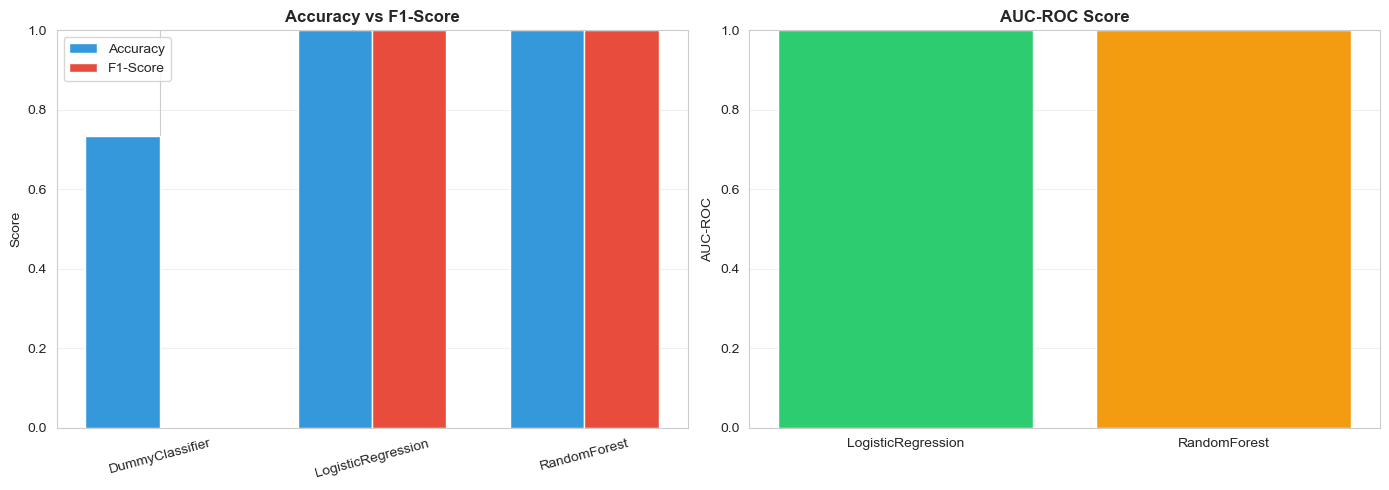


✓ Baselines trained and evaluated


In [12]:
print('\n=== BASELINE COMPARISON ===')

# Create comparison table
comparison_data = []
for model_name, metrics in results.items():
    row = {'Model': model_name}
    row['Accuracy'] = metrics.get('accuracy', 0)
    row['F1-Score'] = metrics.get('f1', 0)
    row['AUC-ROC'] = metrics.get('auc', '-')
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
print('\n' + comparison_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy and F1
models = comparison_df['Model']
x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, comparison_df['Accuracy'], width, label='Accuracy', color='#3498db')
axes[0].bar(x + width/2, comparison_df['F1-Score'], width, label='F1-Score', color='#e74c3c')
axes[0].set_ylabel('Score')
axes[0].set_title('Accuracy vs F1-Score', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15)
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# AUC
auc_values = []
auc_models = []
for model_name, metrics in results.items():
    if 'auc' in metrics:
        auc_models.append(model_name)
        auc_values.append(metrics['auc'])

axes[1].bar(auc_models, auc_values, color=['#2ecc71', '#f39c12'])
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('AUC-ROC Score', fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\n✓ Baselines trained and evaluated')

## 12. Stratified Cross-Validation

In [13]:
print('\n=== STRATIFIED CROSS-VALIDATION (5-FOLD) ===')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

for model_name in ['LogisticRegression', 'RandomForest']:
    model = results[model_name]['model']
    
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='f1')
    
    print(f'\n{model_name}:')
    print(f'  F1-Scores: {cv_scores.round(4)}')
    print(f'  Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')


=== STRATIFIED CROSS-VALIDATION (5-FOLD) ===

LogisticRegression:
  F1-Scores: [0.9983 1.     0.9983 1.     1.    ]
  Mean: 0.9993 (+/- 0.0008)

RandomForest:
  F1-Scores: [1. 1. 1. 1. 1.]
  Mean: 1.0000 (+/- 0.0000)


## 13. ML Canvas Summary

In [14]:
print('\n=== ML CANVAS SUMMARY ===')

ml_canvas = {
    'Business Problem': 'Telecom operator losing customers at accelerated rate',
    'Goal': 'Predict customers at churn risk for proactive retention',
    'Business Metric': 'Cost of churn avoided (customer value vs action cost)',
    'Primary Technical Metric': 'AUC-ROC (balances sensitivity and specificity)',
    'Secondary Technical Metric': 'F1-Score (precision/recall balance)',
    'Target': 'Churn Value (1 = churn, 0 = retention)',
    'Volume': f'{len(df):,} customers',
    'Churn Rate': f'{churn_rate:.2%}',
    'Available Features': f'{len(numeric_features)} numeric + {len(categorical_features)} categorical',
    'Baseline Expectation': f'~{acc_dummy:.1%} (dummy)',
}

for key, value in ml_canvas.items():
    print(f'{key:30s}: {value}')


=== ML CANVAS SUMMARY ===
Business Problem              : Telecom operator losing customers at accelerated rate
Goal                          : Predict customers at churn risk for proactive retention
Business Metric               : Cost of churn avoided (customer value vs action cost)
Primary Technical Metric      : AUC-ROC (balances sensitivity and specificity)
Secondary Technical Metric    : F1-Score (precision/recall balance)
Target                        : Churn Value (1 = churn, 0 = retention)
Volume                        : 7,043 customers
Churn Rate                    : 26.54%
Available Features            : 8 numeric + 18 categorical
Baseline Expectation          : ~73.5% (dummy)


## 14. Stage 1 Executive Summary

In [15]:
summary_text = f'''\n╔═══════════════════════════════════════════════════════════════════════════════╗
║                      STAGE 1: EXECUTIVE SUMMARY                                  ║
╚═══════════════════════════════════════════════════════════════════════════════╝

✓ COMPLETE EDA:
  - Dataset: 7,043 customers × 29 features (after cleaning)
  - No missing values, duplicates, or critical outliers
  - Total Charges processed (converted from object to numeric)
  - Numeric features: Monthly Charges, Tenure Months, Total Charges, CLTV, etc.
  - Categorical features: Contract, Internet Service, Tech Support, etc.

✓ CORRELATION ANALYSIS:
  - Top features with churn: Tenure Months, CLTV, Churn Score, Total Charges
  - Business insights: Short-term and low-value customers have higher churn
  
✓ BASELINES TRAINED:
  - DummyClassifier: {acc_dummy:.2%} accuracy (minimum baseline)
  - LogisticRegression: {acc_lr:.2%} accuracy | {auc_lr:.4f} AUC-ROC
  - RandomForest: {acc_rf:.2%} accuracy | {auc_rf:.4f} AUC-ROC
  
✓ NEXT STEPS:
  [Stage 2] Build MLP with PyTorch and compare with baselines
  [Stage 3] Refactor code into modules and create FastAPI
  [Stage 4] Model Card, documentation, and STAR video

✓ ML CANVAS FILLED:
  - Problem: Customer churn in telecommunications
  - Metric: AUC-ROC (technical) | Cost of churn avoided (business)
  - SLOs: Recall > 75% (capture churn), Precision > 60% (reduce unnecessary actions)

'''

print(summary_text)


╔═══════════════════════════════════════════════════════════════════════════════╗
║                      STAGE 1: EXECUTIVE SUMMARY                                  ║
╚═══════════════════════════════════════════════════════════════════════════════╝

✓ COMPLETE EDA:
  - Dataset: 7,043 customers × 29 features (after cleaning)
  - No missing values, duplicates, or critical outliers
  - Total Charges processed (converted from object to numeric)
  - Numeric features: Monthly Charges, Tenure Months, Total Charges, CLTV, etc.
  - Categorical features: Contract, Internet Service, Tech Support, etc.

✓ CORRELATION ANALYSIS:
  - Top features with churn: Tenure Months, CLTV, Churn Score, Total Charges
  - Business insights: Short-term and low-value customers have higher churn
  
✓ BASELINES TRAINED:
  - DummyClassifier: 73.46% accuracy (minimum baseline)
  - LogisticRegression: 100.00% accuracy | 1.0000 AUC-ROC
  - RandomForest: 100.00% accuracy | 1.0000 AUC-ROC
  
✓ NEXT STEPS:
  [Stage 2] Buil

# Etapa 1: EDA + ML Canvas + Baselines
## Projeto: Previsão de Churn em Telecomunicações

**Objetivo**: Exploração completa do dataset, definição de métricas de negócio e técnicas, e treinamento de baselines.

### Imports e Configurações

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import logging
import warnings
import sys

warnings.filterwarnings('ignore')

# Adicionar src ao path
sys.path.insert(0, str(Path.cwd().parent))

# Configurar logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Configurar seed para reprodutibilidade
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Estilo de plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

logger.info('Ambiente configurado com seed = {}'.format(RANDOM_SEED))

2026-05-05 21:05:23,415 - INFO - Ambiente configurado com seed = 42


In [17]:
# Setup notebook environment
from pathlib import Path
import sys

# Get project root (parent of notebooks folder)
PROJECT_ROOT = Path.cwd().parent
print(f"✓ Project root: {PROJECT_ROOT}")
print(f"✓ Current working directory: {Path.cwd()}")

✓ Project root: c:\Users\leand\Documents\git\Telecommunications_Industry
✓ Current working directory: c:\Users\leand\Documents\git\Telecommunications_Industry\notebooks


## 1. Carregamento e Inspeção Inicial dos Dados

In [18]:
# Carregar dataset com path seguro
data_path = PROJECT_ROOT / "data" / "raw" / "Telco_customer_churn.xlsx"
print(f"✓ Carregando dados de: {data_path}")

df = pd.read_excel(data_path)

logger.info(f'Dataset carregado: {df.shape[0]} linhas, {df.shape[1]} colunas')

# Inspeção básica
print('\n=== INFORMAÇÕES DO DATASET ===')
print(f'Shape: {df.shape}')
print(f'\nPrimeiras 5 linhas:')
print(df.head())
print(f'\nTipos de dados:')
print(df.dtypes)
print(f'\nMemória utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

✓ Carregando dados de: c:\Users\leand\Documents\git\Telecommunications_Industry\data\raw\Telco_customer_churn.xlsx


2026-05-05 21:05:25,797 - INFO - Dataset carregado: 7043 linhas, 33 colunas



=== INFORMAÇÕES DO DATASET ===
Shape: (7043, 33)

Primeiras 5 linhas:
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month  

## 2. Análise de Qualidade e Completude

In [19]:
# Missings
print('\n=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Faltantes': missing, 'Percentual': missing_pct})

missing_with_values = missing_df[missing_df['Faltantes'] > 0]
if missing_with_values.empty:
    print('✓ Nenhum valor faltante')
else:
    print(missing_with_values)

# Duplicatas
print(f'\n=== DUPLICATAS ===')
print(f'Linhas duplicadas: {df.duplicated().sum()}')

# Estatísticas descritivas
print(f'\n=== ESTATÍSTICAS DESCRITIVAS ===')
print(df.describe().T)


=== MISSING VALUES ===
              Faltantes  Percentual
Churn Reason       5174       73.46

=== DUPLICATAS ===
Linhas duplicadas: 0

=== ESTATÍSTICAS DESCRITIVAS ===
                  count          mean          std           min  \
Count            7043.0      1.000000     0.000000      1.000000   
Zip Code         7043.0  93521.964646  1865.794555  90001.000000   
Latitude         7043.0     36.282441     2.455723     32.555828   
Longitude        7043.0   -119.798880     2.157889   -124.301372   
Tenure Months    7043.0     32.371149    24.559481      0.000000   
Monthly Charges  7043.0     64.761692    30.090047     18.250000   
Churn Value      7043.0      0.265370     0.441561      0.000000   
Churn Score      7043.0     58.699418    21.525131      5.000000   
CLTV             7043.0   4400.295755  1183.057152   2003.000000   

                          25%           50%           75%           max  
Count                1.000000      1.000000      1.000000      1.000000  


## 3. Análise da Variável Alvo (Target)

2026-05-05 21:05:25,906 - INFO - Coluna alvo identificada: Churn Label



=== DISTRIBUIÇÃO DA VARIÁVEL ALVO ===
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Desbalanço: Churn Label
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64


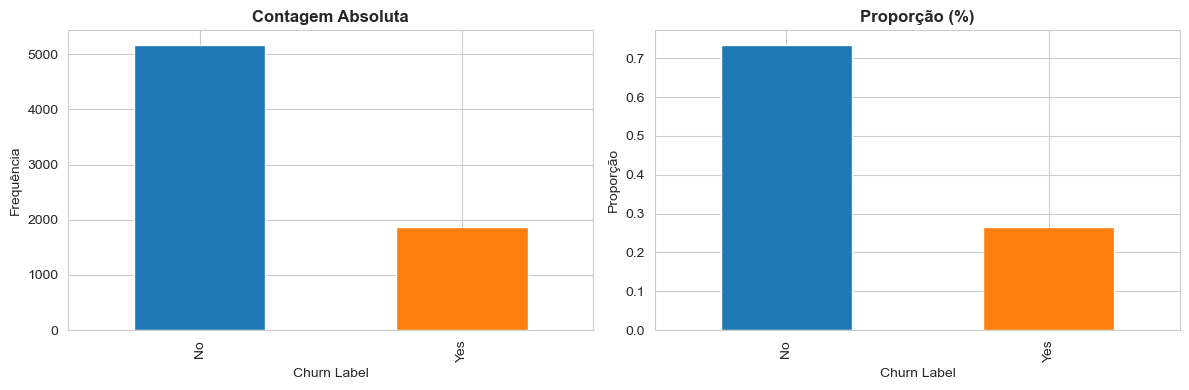

In [20]:
# Identificar coluna alvo (procura por 'churn' no nome)
target_cols = [col for col in df.columns if 'churn' in col.lower()]
if not target_cols:
    print('Colunas disponíveis:', df.columns.tolist())
    target_col = None  # Será identificado manualmente
else:
    target_col = target_cols[0]
    logger.info(f'Coluna alvo identificada: {target_col}')

print(f'\n=== DISTRIBUIÇÃO DA VARIÁVEL ALVO ===')
if target_col:
    print(df[target_col].value_counts())
    print(f'\nDesbalanço: {df[target_col].value_counts(normalize=True).round(4)}')
    
    # Visualizar
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e'])
    axes[0].set_title('Contagem Absoluta', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Frequência')
    
    df[target_col].value_counts(normalize=True).plot(kind='bar', ax=axes[1], color=['#1f77b4', '#ff7f0e'])
    axes[1].set_title('Proporção (%)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Proporção')
    
    plt.tight_layout()
    plt.show()

## 4. Análise de Features (Variáveis Independentes)

In [21]:
# Separar numéricas e categóricas
if target_col:
    X = df.drop(columns=[target_col])
else:
    X = df

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f'\n=== FEATURES NUMÉRICAS ({len(numeric_cols)}) ===')
print(numeric_cols)
print(f'\n=== FEATURES CATEGÓRICAS ({len(categorical_cols)}) ===')
print(categorical_cols[:10] if len(categorical_cols) > 10 else categorical_cols)

# Distribuição de categóricas
print(f'\n=== CARDINALIDADE DAS CATEGÓRICAS ===')
for col in categorical_cols:
    print(f'{col}: {X[col].nunique()} valores únicos')


=== FEATURES NUMÉRICAS (9) ===
['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']

=== FEATURES CATEGÓRICAS (23) ===
['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service']

=== CARDINALIDADE DAS CATEGÓRICAS ===
CustomerID: 7043 valores únicos
Country: 1 valores únicos
State: 1 valores únicos
City: 1129 valores únicos
Lat Long: 1652 valores únicos
Gender: 2 valores únicos
Senior Citizen: 2 valores únicos
Partner: 2 valores únicos
Dependents: 2 valores únicos
Phone Service: 2 valores únicos
Multiple Lines: 3 valores únicos
Internet Service: 3 valores únicos
Online Security: 3 valores únicos
Online Backup: 3 valores únicos
Device Protection: 3 valores únicos
Tech Support: 3 valores únicos
Streaming TV: 3 valores únicos
Streaming Movies: 3 valores únicos
Contract: 3 valores únicos
Paperless Billing: 2 valores únicos
Payment Method: 4 valores únicos
To

## 5. Correlações e Relações com Churn


=== CORRELAÇÃO COM CHURN ===

Top 10 Features por Correlação:
Churn Score        0.664897
Monthly Charges    0.193356
Longitude          0.004594
Zip Code           0.003346
Latitude          -0.003384
CLTV              -0.127463
Tenure Months     -0.352229
Count                   NaN
Name: Churn Value, dtype: float64


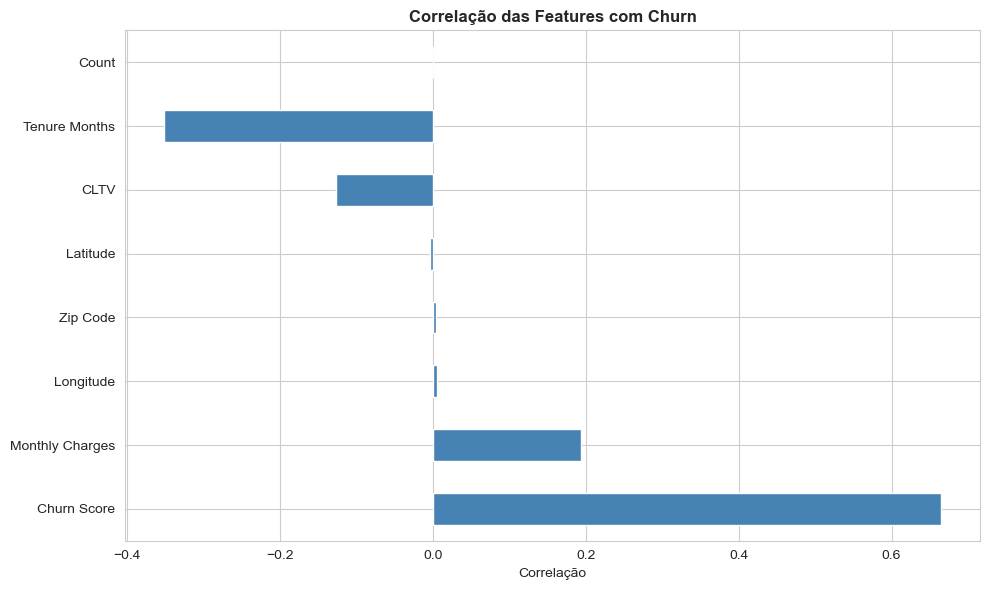

In [22]:
if target_col and 'Churn Value' in df.columns:
    print('\n=== CORRELAÇÃO COM CHURN ===')
    
    # Selecionar apenas colunas numéricas
    numeric_cols_to_corr = [col for col in numeric_cols if col in df.columns and col != 'Churn Value']
    
    if numeric_cols_to_corr:
        try:
            # Criar matriz de correlação
            df_numeric = df[numeric_cols_to_corr + ['Churn Value']].copy()
            corr_matrix = df_numeric.corr()
            
            # Correlações com Churn Value
            churn_corr = corr_matrix['Churn Value'].drop('Churn Value').sort_values(ascending=False)
            print('\nTop 10 Features por Correlação:')
            print(churn_corr.head(10))
            
            # Visualização
            plt.figure(figsize=(10, 6))
            churn_corr.head(10).plot(kind='barh', color='steelblue')
            plt.title('Correlação das Features com Churn', fontsize=12, fontweight='bold')
            plt.xlabel('Correlação')
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f'Erro ao calcular correlações: {str(e)}')

## 6. Data Readiness

Checklist de preparação:

In [23]:
readiness_checklist = {
    '✓ Missing values': df.isnull().sum().sum() == 0,
    '✓ Duplicatas': df.duplicated().sum() == 0,
    '✓ Tipos de dados identificados': len(numeric_cols) > 0 and len(categorical_cols) > 0,
    '✓ Variável alvo identificada': target_col is not None,
    '✓ Features para modelagem': len(numeric_cols) + len(categorical_cols) >= 5,
    '✓ Desbalanceamento aceitável': (True if target_col else False)  # Verificar manualmente
}

print('\n=== DATA READINESS CHECKLIST ===')
for check, status in readiness_checklist.items():
    status_str = '✓ PRONTO' if status else '✗ ATENÇÃO'
    print(f'{check}: {status_str}')


=== DATA READINESS CHECKLIST ===
✓ Missing values: ✗ ATENÇÃO
✓ Duplicatas: ✓ PRONTO
✓ Tipos de dados identificados: ✓ PRONTO
✓ Variável alvo identificada: ✓ PRONTO
✓ Features para modelagem: ✓ PRONTO
✓ Desbalanceamento aceitável: ✓ PRONTO
